Real-World Problem 1: Restaurant Chain – Daily Sales Analysis

 Management is worried
that some branches are underperforming. You are given a dataset of daily sales (₹) for the last 3 months
across 5 outlets

Top Performing Outlet
EDA
Prepare a summary report: Which outlet is the most consistent? Which one has many ups and
downs?



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('/content/Restaurant Sales Dataset.xlsx')


In [ ]:
df.shape

(92, 6)

In [ ]:
df.isnull().sum()

,0
Date,0
Outlet_A,0
Outlet_B,0
Outlet_C,0
Outlet_D,0
Outlet_E,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      92 non-null     datetime64[ns]
 1   Outlet_A  92 non-null     int64         
 2   Outlet_B  92 non-null     int64         
 3   Outlet_C  92 non-null     int64         
 4   Outlet_D  92 non-null     int64         
 5   Outlet_E  92 non-null     int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 4.4 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,Date,Outlet_A,Outlet_B,Outlet_C,Outlet_D,Outlet_E
0,2025-06-01,15270,21439,6059,24257,7225
1,2025-06-02,8860,22892,11668,24486,11893
2,2025-06-03,13390,21863,14914,15534,14022
3,2025-06-04,13191,22916,8157,14061,16151
4,2025-06-05,19964,23529,10915,21561,12600


In [ ]:
df.tail()

,Date,Outlet_A,Outlet_B,Outlet_C,Outlet_D,Outlet_E
87,2025-08-27,15629,21374,9736,18754,8148
88,2025-08-28,19990,21892,6802,20677,13293
89,2025-08-29,17467,16678,13155,15895,13457
90,2025-08-30,9016,18242,13120,13354,14509
91,2025-08-31,15869,19636,11616,24362,16907


In [ ]:
df.describe ()

,Date,Outlet_A,Outlet_B,Outlet_C,Outlet_D,Outlet_E
count,92,92.000000,92.000000,92.000000,92.000000,92.000000
mean,2025-07-16 12:00:00,14403.847826,22320.630435,10064.271739,18033.358696,12305.532609
min,2025-06-01 00:00:00,8161.000000,15064.000000,5197.000000,10098.000000,7154.000000
25%,2025-06-23 18:00:00,11132.250000,19599.000000,7479.500000,14478.000000,9357.750000
50%,2025-07-16 12:00:00,14646.500000,21986.500000,10240.500000,18201.000000,12612.500000
75%,2025-08-08 06:00:00,17675.500000,24939.000000,12392.000000,22016.000000,14852.500000
max,2025-08-31 00:00:00,19990.000000,29948.000000,14986.000000,24681.000000,17966.000000
std,NaN,3610.368661,4156.492278,2842.945946,4428.411691,3284.383949


In [17]:
all = ['Outlet_A','Outlet_B','Outlet_C','Outlet_D','Outlet_E']

In [44]:
# Calculate Max, Min, and Range for all outlets
max_sales = df[all].max()
min_sales = df[all].min()
range_sales = max_sales - min_sales

# Combine into a summary DataFrame
range_summary = pd.DataFrame({
    'Min Sales (₹)': min_sales,
    'Max Sales (₹)': max_sales,
    'Range (₹)': range_sales
})

print("Sales Range per Outlet:")
print(range_summary)

Sales Range per Outlet:
          Min Sales (₹)  Max Sales (₹)  Range (₹)
Outlet_A           8161          19990      11829
Outlet_B          15064          29948      14884
Outlet_C           5197          14986       9789
Outlet_D          10098          24681      14583
Outlet_E           7154          17966      10812


In [18]:
Q1 =df[all].quantile(0.25)
Q3 =df[all].quantile(0.75)
IQR =Q3-Q1
lower_bound =Q1-IQR*1.5
upper_bound= Q3+IQR*1.5
outliers=(df[all]>upper_bound)|(df[all]<lower_bound)
print (outliers.sum ())

Outlet_A    0
Outlet_B    0
Outlet_C    0
Outlet_D    0
Outlet_E    0
dtype: int64


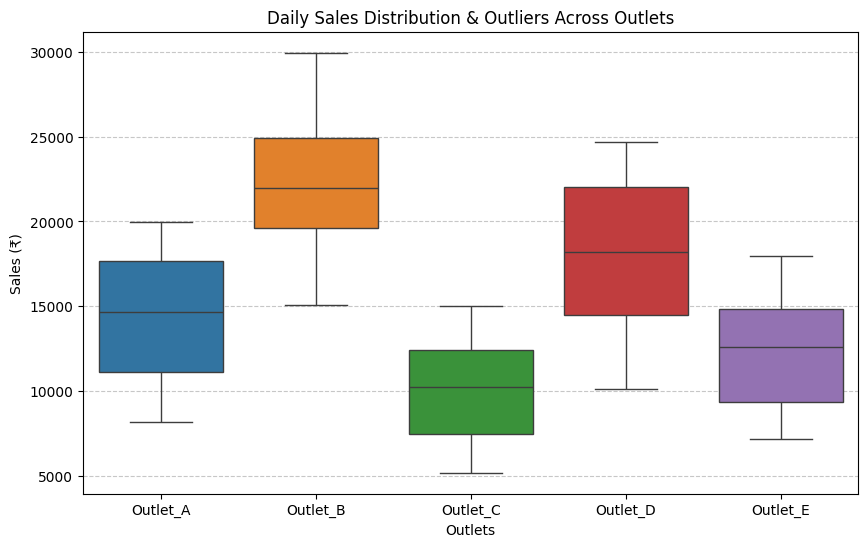

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[all])

plt.title('Daily Sales Distribution & Outliers Across Outlets')
plt.xlabel('Outlets')
plt.ylabel('Sales (₹)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [29]:
# Total sales for each outlet across the entire 3 months
total_per_outlet = df[all].sum()

# Total overall sales across all 5 outlets combined
overall_total = df[all].sum().sum()

print("Total Sales per Outlet (₹):")
print(total_per_outlet)
print(f"\nOverall Total Sales Across All Outlets: ₹{overall_total:,.2f}")

Total Sales per Outlet (₹):
Outlet_A    1325154
Outlet_B    2053498
Outlet_C     925913
Outlet_D    1659069
Outlet_E    1132109
dtype: int64

Overall Total Sales Across All Outlets: ₹7,095,743.00


/tmp/ipykernel_1263/1457925488.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_per_outlet.index, y=total_per_outlet.values, palette='Blues_r')


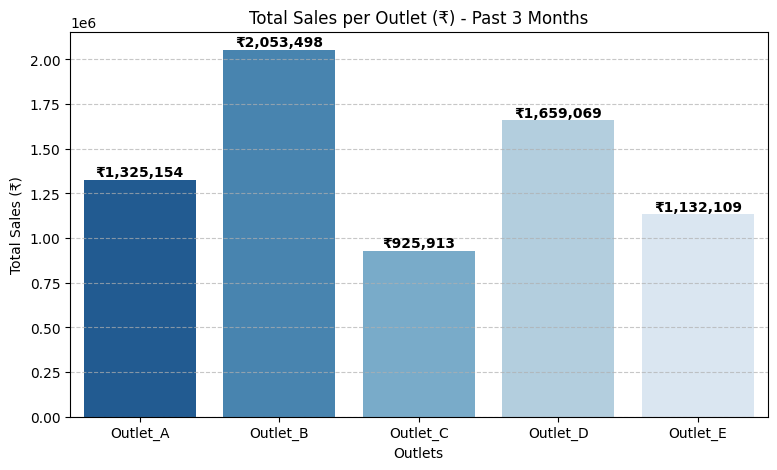

In [30]:
plt.figure(figsize=(9, 5))
sns.barplot(x=total_per_outlet.index, y=total_per_outlet.values, palette='Blues_r')

plt.title('Total Sales per Outlet (₹) - Past 3 Months')
plt.xlabel('Outlets')
plt.ylabel('Total Sales (₹)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate values on top of each bar
for i, v in enumerate(total_per_outlet.values):
    plt.text(i, v + 20000, f"₹{v:,.0f}", ha='center', fontweight='bold')

plt.show()

/tmp/ipykernel_1263/356969440.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_sales.index, y=mean_sales.values, palette='viridis')


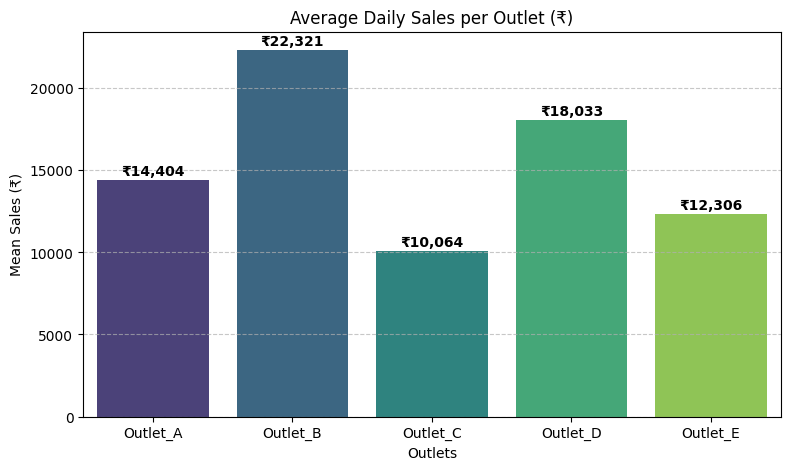

In [23]:
# Calculate average sales
mean_sales = df[all].mean()

plt.figure(figsize=(9, 5))
sns.barplot(x=mean_sales.index, y=mean_sales.values, palette='viridis')

plt.title('Average Daily Sales per Outlet (₹)')
plt.xlabel('Outlets')
plt.ylabel('Mean Sales (₹)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate values on top of each bar
for i, v in enumerate(mean_sales.values):
    plt.text(i, v + 300, f"₹{v:,.0f}", ha='center', fontweight='bold')

plt.show()

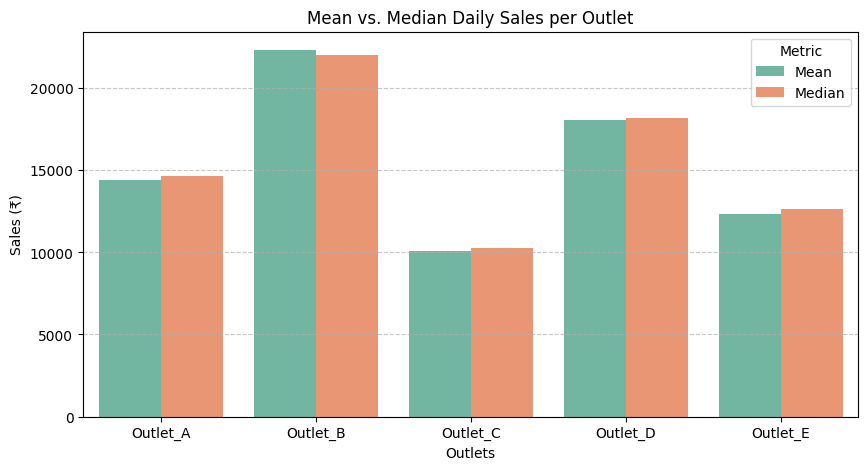

In [24]:
# Create a summary DataFrame
avg_df = pd.DataFrame({
    'Mean': df[all].mean(),
    'Median': df[all].median()
}).reset_index().rename(columns={'index': 'Outlet'})

# Melt for Seaborn plotting
avg_long = avg_df.melt(id_vars='Outlet', var_name='Metric', value_name='Sales')

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_long, x='Outlet', y='Sales', hue='Metric', palette='Set2')

plt.title('Mean vs. Median Daily Sales per Outlet')
plt.xlabel('Outlets')
plt.ylabel('Sales (₹)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [25]:
# Set Date as index or extract Month Name / Year-Month
df['Month'] = df['Date'].dt.to_period('M') # e.g., '2025-06', '2025-07', '2025-08'

# Group by Month and calculate average sales for each outlet
monthly_avg = df.groupby('Month')[all].mean().reset_index()

# Convert Month back to string for easier plotting
monthly_avg['Month'] = monthly_avg['Month'].astype(str)

print("Monthly Average Sales per Outlet:")
print(monthly_avg)

Monthly Average Sales per Outlet:
     Month      Outlet_A      Outlet_B      Outlet_C      Outlet_D  \
0  2025-06  14353.900000  21547.633333  10350.833333  18509.833333   
1  2025-07  14392.290323  24629.322581   9702.741935  18054.580645   
2  2025-08  14463.741935  20760.000000  10148.483871  17551.032258   

       Outlet_E  
0  12157.833333  
1  11706.225806  
2  13047.774194  


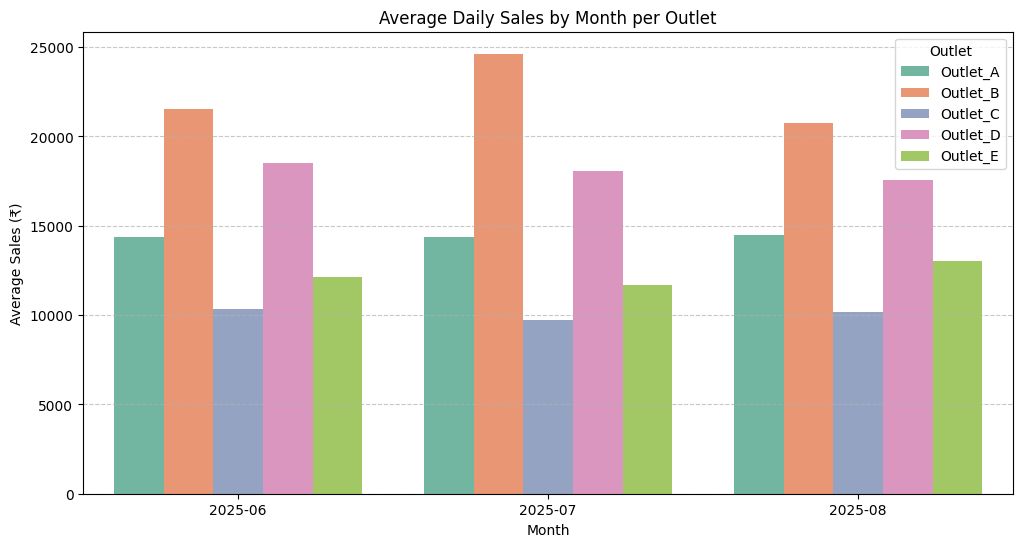

In [26]:
# Reshape data for plotting
monthly_avg_long = monthly_avg.melt(id_vars='Month', var_name='Outlet', value_name='Avg_Sales')

plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_avg_long, x='Month', y='Avg_Sales', hue='Outlet', palette='Set2')

plt.title('Average Daily Sales by Month per Outlet')
plt.xlabel('Month')
plt.ylabel('Average Sales (₹)')
plt.legend(title='Outlet')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

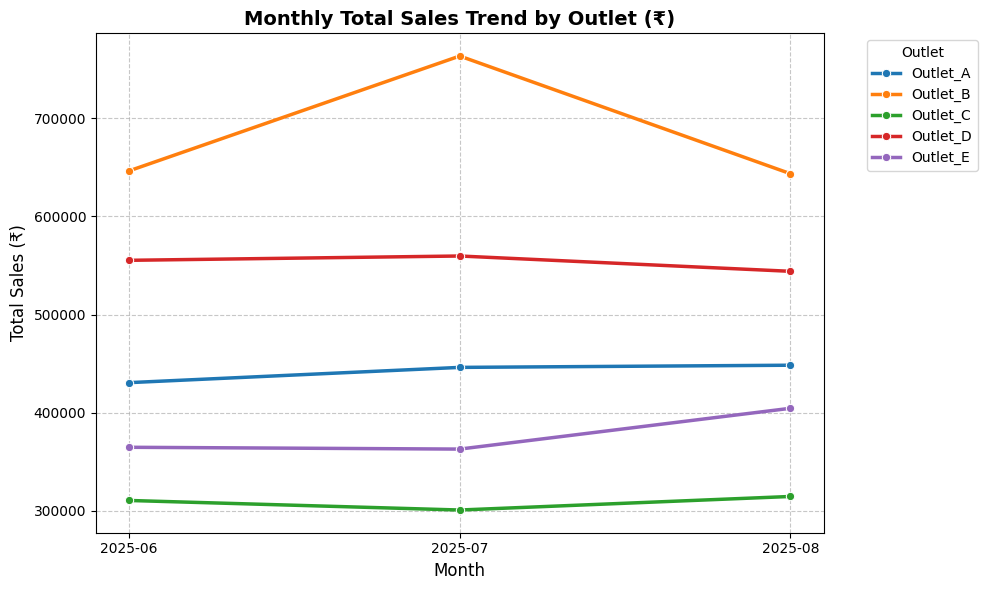

In [45]:
# Calculate total monthly sales per outlet
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly_totals = df.groupby('Month')[all].sum().reset_index()

# Melt into long format for line plotting
monthly_totals_long = monthly_totals.melt(id_vars='Month', var_name='Outlet', value_name='Total_Sales')

# Plot Line Chart
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=monthly_totals_long,
    x='Month',
    y='Total_Sales',
    hue='Outlet',
    marker='o',
    linewidth=2.5,
    palette='tab10'
)

plt.title('Monthly Total Sales Trend by Outlet (₹)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Outlet', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

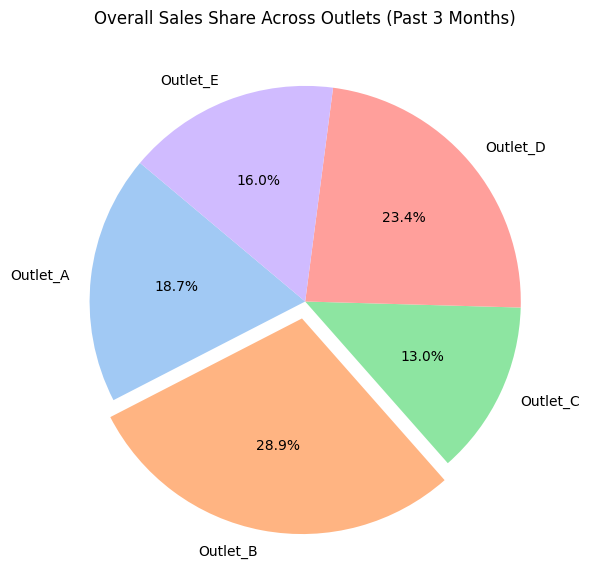

In [33]:
# Total sales per outlet overall
total_sales = df[all].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    total_sales,
    labels=total_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel'),
    explode=(0, 0.08, 0, 0, 0)  # Highlights Outlet_B (highest contributor)
)

plt.title('Overall Sales Share Across Outlets (Past 3 Months)')
plt.show()

In [35]:
# Extract Year-Month from Date
df['Month'] = df['Date'].dt.to_period('M').astype(str)

# Group by Month and sum sales for all outlets
monthly_totals = df.groupby('Month')[all].sum().reset_index()

print("Monthly Total Sales per Outlet (₹):")
print(monthly_totals)

Monthly Total Sales per Outlet (₹):
     Month  Outlet_A  Outlet_B  Outlet_C  Outlet_D  Outlet_E
0  2025-06    430617    646429    310525    555295    364735
1  2025-07    446161    763509    300785    559692    362893
2  2025-08    448376    643560    314603    544082    404481


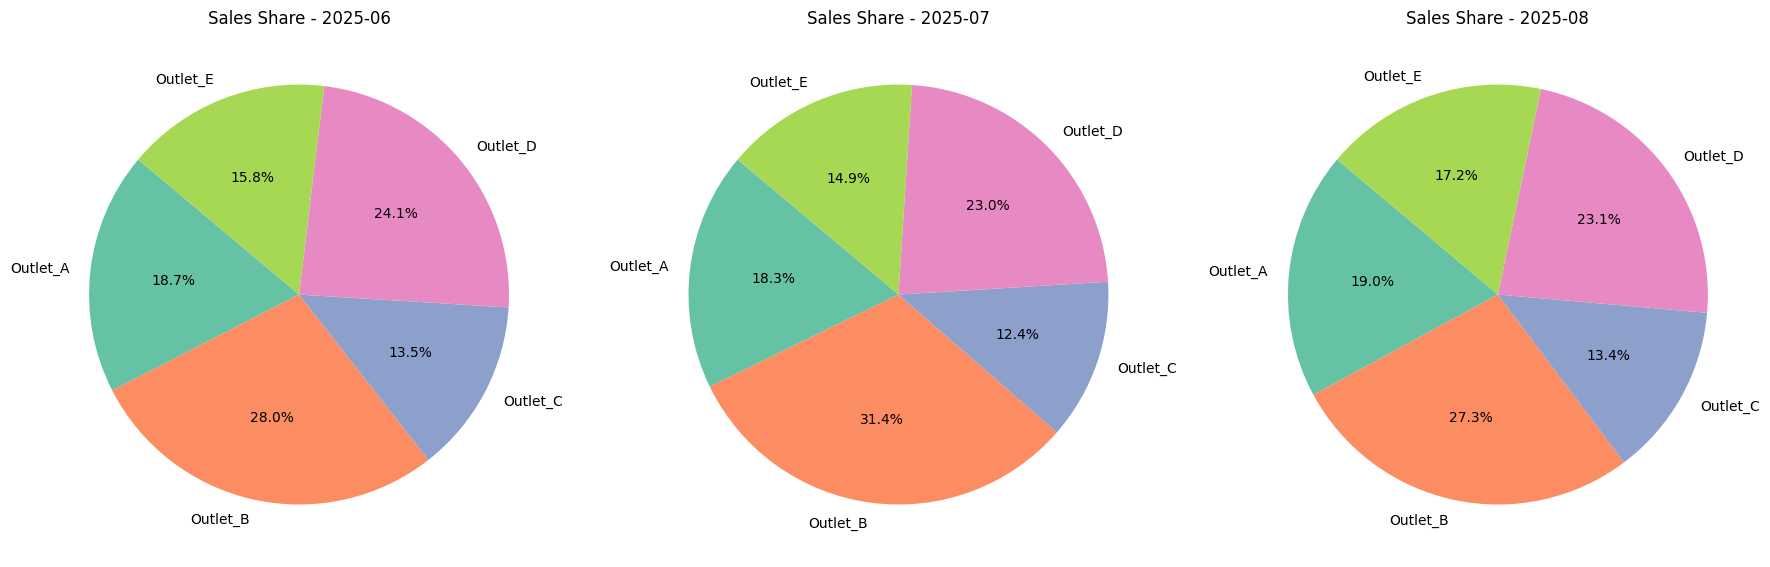

In [38]:
# Group total sales by month
monthly_totals = df.groupby('Month')[all].sum()

# Create side-by-side pie charts for June, July, and August
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, month in zip(axes, monthly_totals.index):
    ax.pie(
        monthly_totals.loc[month],
        labels=monthly_totals.columns,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('Set2')
    )
    ax.set_title(f'Sales Share - {month}')

plt.tight_layout()
plt.show()

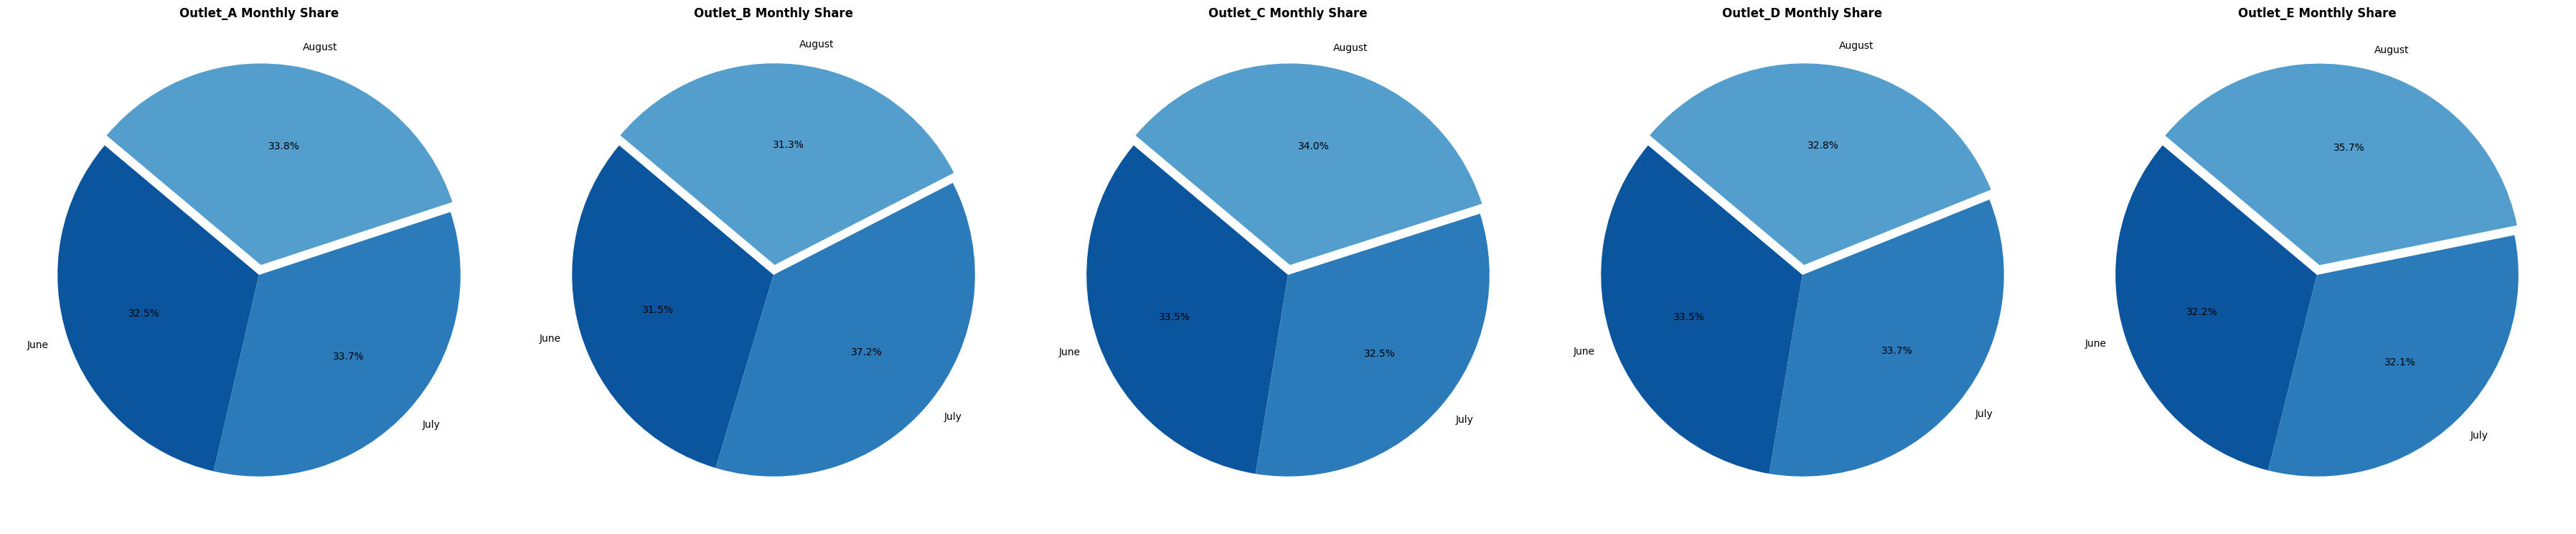

In [42]:
# Convert Period to full month name (e.g., 'June', 'July', 'August')
df['Month_Name'] = df['Date'].dt.strftime('%B')

# Group total sales by Month_Name for each outlet
# Reindexing ensures months stay in correct chronological order
months_order = ['June', 'July', 'August']
outlet_cols = ['Outlet_A', 'Outlet_B', 'Outlet_C', 'Outlet_D', 'Outlet_E']

monthly_per_outlet = df.groupby('Month_Name')[outlet_cols].sum().reindex(months_order)

# Create a 1x5 grid of pie charts (one for each outlet)
fig, axes = plt.subplots(1, 5, figsize=(36, 22))

for ax, col in zip(axes, outlet_cols):
    ax.pie(
        monthly_per_outlet[col],
        labels=monthly_per_outlet.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('Blues_r'),
        explode=(0, 0, 0.05)  # Slightly pops out August
    )
    ax.set_title(f'{col} Monthly Share', fontweight='bold')

plt.tight_layout()
plt.show()


#Top Performer (#1 - Outlet_B)

## Outlet_B generated ₹20.53 Lakhs, accounting for nearly 29% of all sales generated across all 5 branches combined.

##Consistently High Baseline: Half of Outlet_B's operational days generated over ₹21,986 (Median), making its baseline performance higher than any other outlet's peak daily sales except Outlet_D.

##Monthly Leader: Outlet_B ranked as the #1 sales generator in all three individual months (June: ₹6.46L, July: ₹7.63L, August: ₹6.43L).
---

#Middle Tier (#2 to #4):
 ##Outlet_D leads the middle group strong in volume but experiences significant day-to-day fluctuations. Outlet_A shows steady, progressive month-over-month growth, while Outlet_E closed August with a strong performance spike.
 ---


#Bottom Performer (#5 - Outlet_C):
##Generates the lowest overall revenue (13.0% share), but operates as the most predictable and stable outlet with the narrowest variance in daily sales.